# Dataset Exploratory Data Analysis (EDA)
Logan Wong

law3082

In [ ]:
import os

# to read the data
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"]="6"
# YES, it should be "6", rather than 6

In [36]:
# See your current folder
print(f"Current Directory: {os.getcwd()}")

# list everything in this folder
print(f"Files in this directory: {os.listdir('.')}")

Current Directory: /home/stu5/s5/law3082/Courses/IDAI780/Capstone/scripts
Files in this directory: ['baseline_data_splitting.ipynb', '.ipynb_checkpoints', 'dataset_EDA.ipynb', 'baseline_PMF_Embeddings.ipynb', 'view_test_set.ipynb']


In [37]:
# Load your ratings
folder = "../data/ml-1m/"
filename = "ratings.dat"
full_filename = folder + filename

nonchronological_ratings = pd.read_csv(full_filename, sep='::', names=['UserID', 'MovieID', 'Rating', 'Timestamp'])
ratings = nonchronological_ratings.sort_values(['UserID', 'Timestamp'])

/tmp/ipykernel_4032481/1669099963.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  nonchronological_ratings = pd.read_csv(full_filename, sep='::', names=['UserID', 'MovieID', 'Rating', 'Timestamp'])


In [38]:
# Load Movies data
movies = pd.read_csv(f'{folder}movies.dat', sep='::', engine='python', encoding='latin-1', names=['MovieID', 'Title', 'Genres'])

# How many ratings each Movie got

In [39]:
# Group the movies data by MovieID and count the number of ratings
movie_popularity_len = ratings.groupby('MovieID').size().rename('rating_freq')

# Convert that Series into a dictionary: {MovieID: Count}
movie_popularity_dict = movie_popularity_len.to_dict()

In [40]:
# print(movie_popularity_dict)

In [41]:
# Sort by descending-- Most # of ratings to least
desc_movie_pop_sorted_dict = dict(sorted(movie_popularity_dict.items(), key=lambda x: x[1], reverse=True))
for k, v in desc_movie_pop_sorted_dict.items():
    print(f"{k}: {v}")

2858: 3428
260: 2991
1196: 2990
1210: 2883
480: 2672
2028: 2653
589: 2649
2571: 2590
1270: 2583
593: 2578
1580: 2538
1198: 2514
608: 2513
2762: 2459
110: 2443
2396: 2369
1197: 2318
527: 2304
1617: 2288
1265: 2278
1097: 2269
2628: 2250
2997: 2241
318: 2227
858: 2223
356: 2194
2716: 2181
296: 2171
1240: 2098
1: 2077
1214: 2024
2916: 1996
457: 1995
3578: 1924
1200: 1820
541: 1800
2987: 1799
1259: 1785
50: 1783
34: 1751
2791: 1731
780: 1730
3175: 1728
1193: 1725
919: 1718
924: 1716
1127: 1715
2355: 1703
1387: 1697
1221: 1692
912: 1669
1036: 1666
1213: 1657
1610: 1652
377: 1650
1291: 1628
2000: 1627
1136: 1599
3114: 1585
1307: 1568
1704: 1548
1721: 1546
1968: 1539
648: 1527
2599: 1522
32: 1511
3793: 1511
2174: 1495
2797: 1491
2291: 1473
2918: 1473
590: 1451
2959: 1451
3471: 1451
1374: 1448
1394: 1434
2683: 1434
592: 1431
1784: 1424
1573: 1421
1304: 1419
3418: 1417
223: 1412
380: 1400
2706: 1389
1225: 1382
1584: 1382
1527: 1377
3481: 1373
1923: 1371
750: 1367
2699: 1367
39: 1362
21: 1356
139

In [42]:
# sort dict by value (ascending) least # of ratings to most
asc_movie_pop_sorted_dict = dict(sorted(movie_popularity_dict.items(), key=lambda x: x[1]))
# asc_movie_pop_sorted_dict

for k, v in asc_movie_pop_sorted_dict.items():
    print(f"{k}: {v}")

127: 1
133: 1
139: 1
142: 1
226: 1
286: 1
311: 1
396: 1
398: 1
402: 1
545: 1
576: 1
579: 1
584: 1
601: 1
624: 1
641: 1
642: 1
644: 1
651: 1
655: 1
658: 1
684: 1
701: 1
717: 1
730: 1
758: 1
763: 1
774: 1
790: 1
792: 1
814: 1
826: 1
843: 1
859: 1
865: 1
868: 1
872: 1
878: 1
989: 1
1115: 1
1118: 1
1165: 1
1316: 1
1386: 1
1430: 1
1470: 1
1579: 1
1630: 1
1709: 1
1714: 1
1724: 1
1764: 1
1815: 1
1820: 1
1830: 1
1832: 1
1843: 1
1852: 1
1908: 1
1915: 1
2039: 1
2213: 1
2214: 1
2217: 1
2218: 1
2226: 1
2235: 1
2254: 1
2277: 1
2308: 1
2438: 1
2484: 1
2556: 1
2563: 1
2584: 1
2592: 1
2619: 1
2703: 1
2742: 1
2845: 1
2909: 1
3065: 1
3151: 1
3164: 1
3172: 1
3202: 1
3209: 1
3220: 1
3229: 1
3237: 1
3277: 1
3280: 1
3290: 1
3291: 1
3297: 1
3312: 1
3315: 1
3321: 1
3323: 1
3376: 1
3382: 1
3458: 1
3460: 1
3530: 1
3607: 1
3647: 1
3656: 1
3722: 1
3779: 1
3842: 1
3881: 1
3890: 1
3904: 1
130: 2
134: 2
138: 2
192: 2
401: 2
439: 2
530: 2
557: 2
572: 2
578: 2
582: 2
591: 2
607: 2
657: 2
660: 2
672: 2
679: 2
690: 2
70

In [43]:
# Setup plotting style
# sns.set(style="whitegrid")
# plt.figure(figsize=(18, 5))

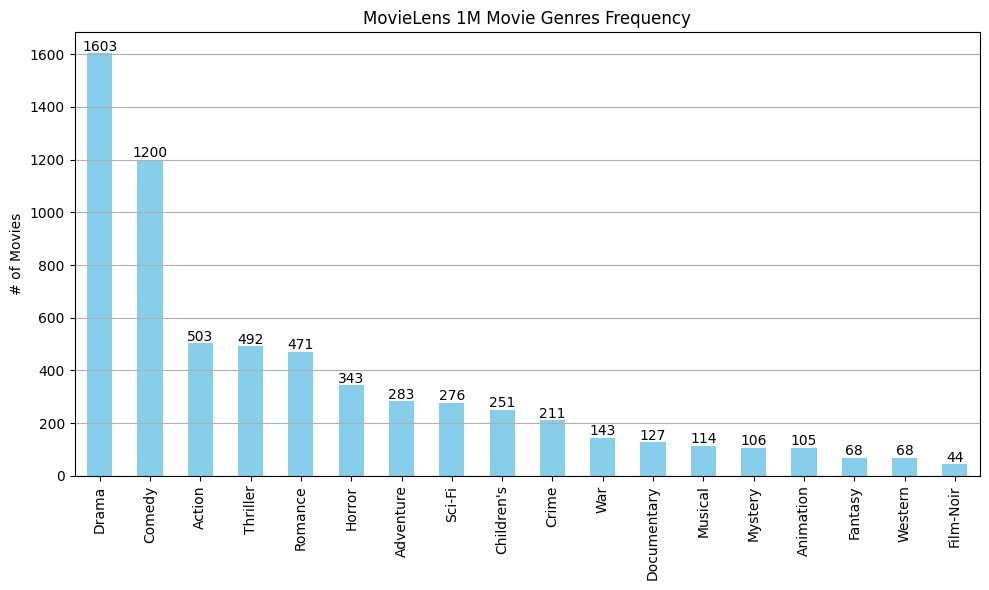

In [44]:
# Plot Movie Genres vs. Frequency
plt.figure(figsize=(10, 6))

# Genres are pipe-separated "|", so split by pipes (e.g. "Action|Adventure") & count individual occurrences
genres_list = movies['Genres'].str.split('|').explode()
genre_counts = genres_list.value_counts()
ax = genre_counts.plot(kind='bar', color='skyblue')

# display exact count on each bar
padding = 10
for i, count in enumerate(genre_counts):
    ax.text(i, count + padding, str(count), ha='center')

plt.title('MovieLens 1M Movie Genres Frequency')
# plt.xlabel('Genre')
plt.ylabel('# of Movies')
plt.xticks(rotation=90)
plt.grid(axis='y')

plt.tight_layout()
plt.savefig('../figures/genre_frequency.png', bbox_inches='tight', dpi=300)
plt.show()

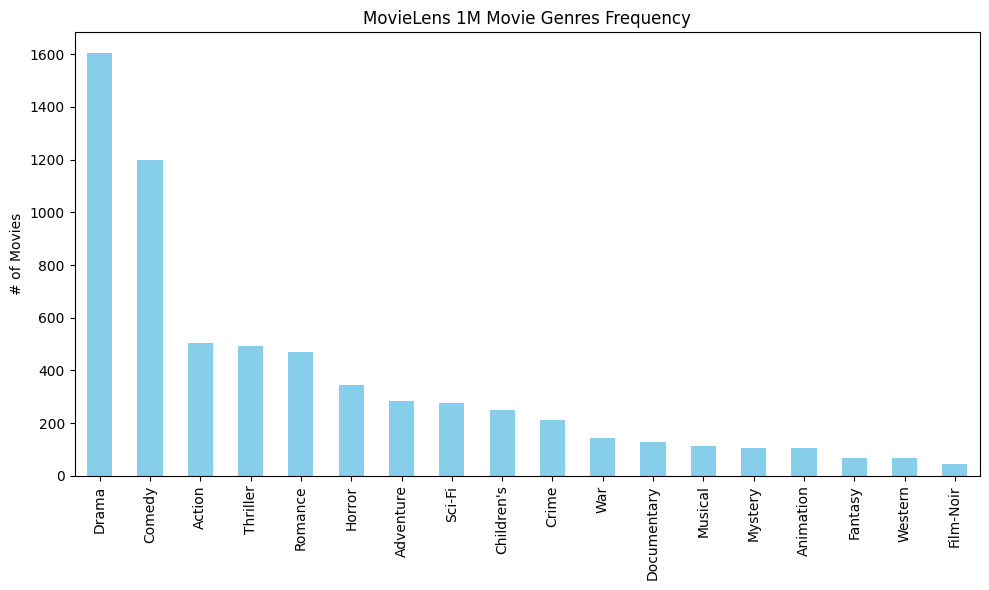

In [45]:
# Plot Movie Genres vs. Frequency
plt.figure(figsize=(10, 6))

# Genres are pipe-separated "|", so split by pipes (e.g. "Action|Adventure") & count individual occurrences
genres_list = movies['Genres'].str.split('|').explode()
genre_counts = genres_list.value_counts()
ax = genre_counts.plot(kind='bar', color='skyblue')

# display exact count on each bar
# padding = 10
# for i, count in enumerate(genre_counts):
    # ax.text(i, count + padding, str(count), ha='center')

plt.title('MovieLens 1M Movie Genres Frequency')
# plt.xlabel('Genre')
plt.ylabel('# of Movies')
plt.xticks(rotation=90)
# plt.grid(axis='y')

plt.tight_layout()
plt.savefig('../figures/genre_frequency_CLEAN.png', bbox_inches='tight', dpi=300)
plt.show()

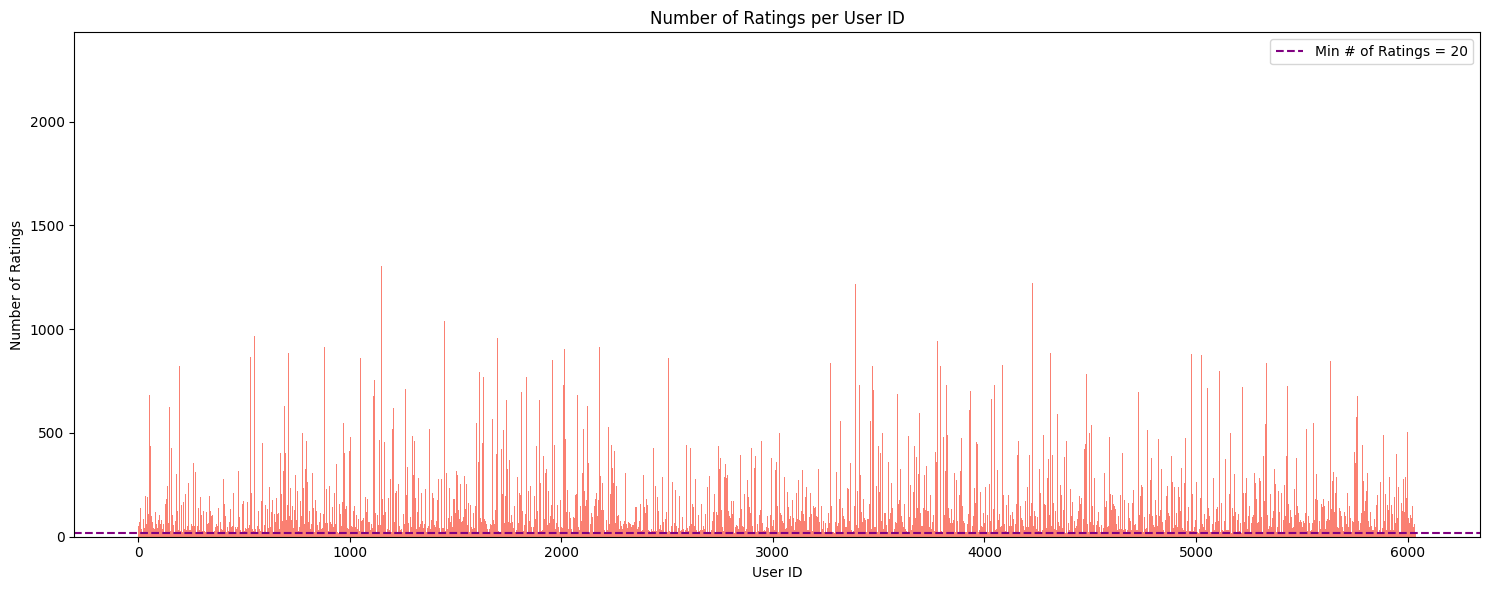

In [14]:
# Plot UserIDs vs # of Ratings
plt.figure(figsize=(15, 6))

# Calculate counts
user_counts = ratings.groupby('UserID').size()

# See all 6,040 users
plt.bar(user_counts.index, user_counts.values, color='salmon', width=1, edgecolor='none')

plt.title('Number of Ratings per User ID')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')

# Min # of ratings line
plt.axhline(y=20, color='purple', linestyle = '--', label='Min # of Ratings = 20')

plt.legend()
plt.tight_layout()
plt.savefig('../figures/ratings_per_user.png', bbox_inches='tight', dpi=300)
plt.show()

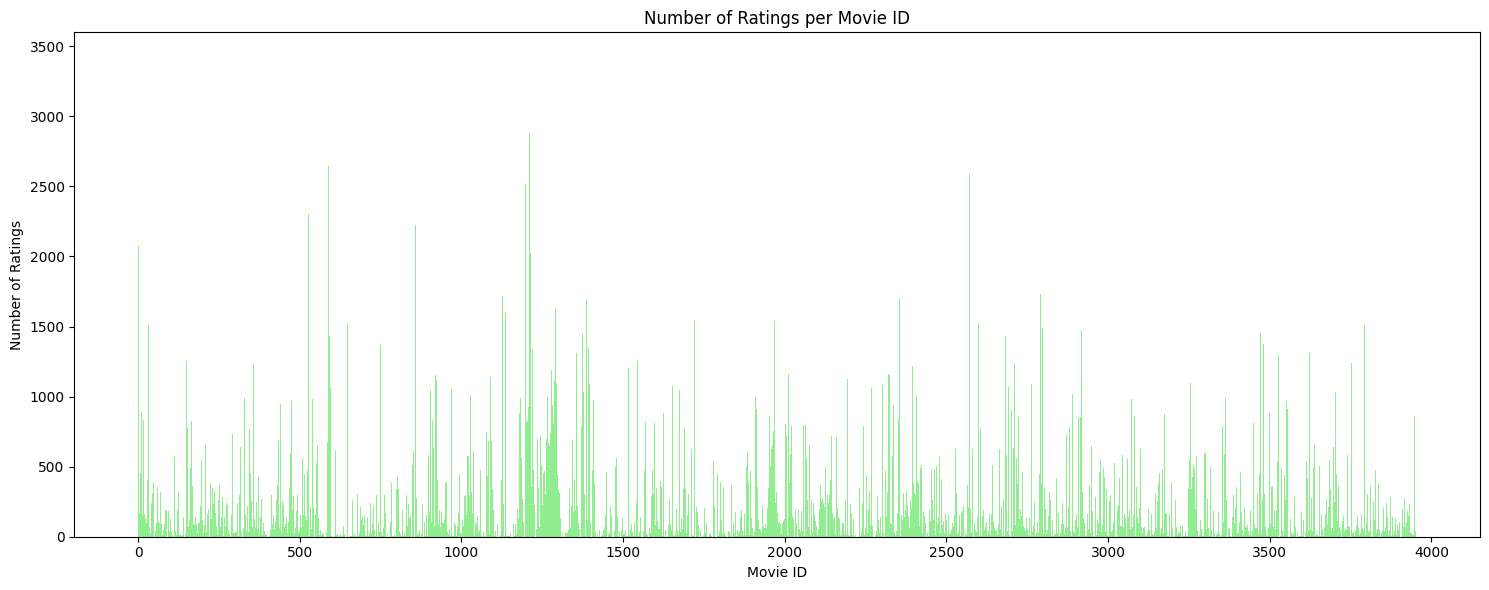

In [15]:
# Plot MovieID vs # of Ratings
plt.figure(figsize=(15, 6))

# Calculate how many times each movie was rated
movie_counts = ratings.groupby('MovieID').size()

# See all 3883 movies
plt.bar(movie_counts.index, movie_counts.values, color='lightgreen', width=1, edgecolor='none')

plt.title('Number of Ratings per Movie ID')
plt.xlabel('Movie ID')
plt.ylabel('Number of Ratings')

plt.tight_layout()
plt.savefig('../figures/ratings_per_movie.png', bbox_inches='tight', dpi=300)
plt.show()

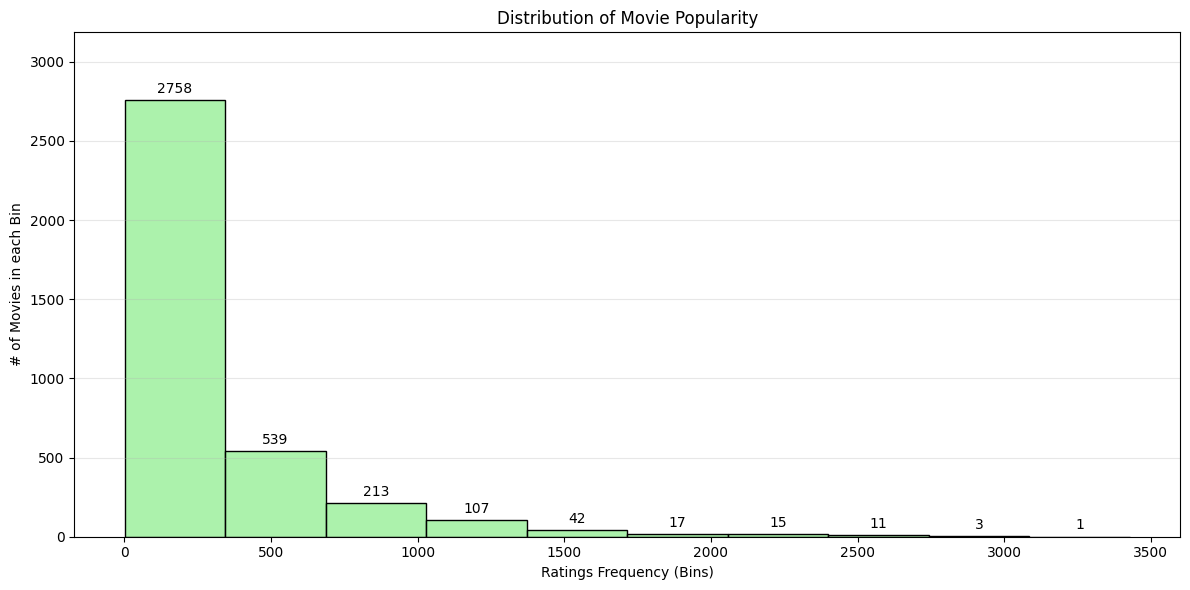

In [16]:
# Extract just the counts (the values from dictionary)
popularity_counts = list(desc_movie_pop_sorted_dict.values())

plt.figure(figsize=(12, 6))
ax = sns.histplot(popularity_counts, bins=10, color='lightgreen', edgecolor='black')

# Add exact counts on top of each bar
# padding=3 pushes the text slightly above the bar
ax.bar_label(ax.containers[0], padding=3)

plt.title('Distribution of Movie Popularity')
plt.xlabel('Ratings Frequency (Bins)')
plt.ylabel('# of Movies in each Bin')

# Add a grid for readability
plt.ylim(0, max(ax.get_ylim()) * 1.1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/movie_popularity_histogram.png', bbox_inches='tight', dpi=300)
plt.show()

1     56174
2    107557
3    261197
4    348971
5    226310
Name: Rating, dtype: int64


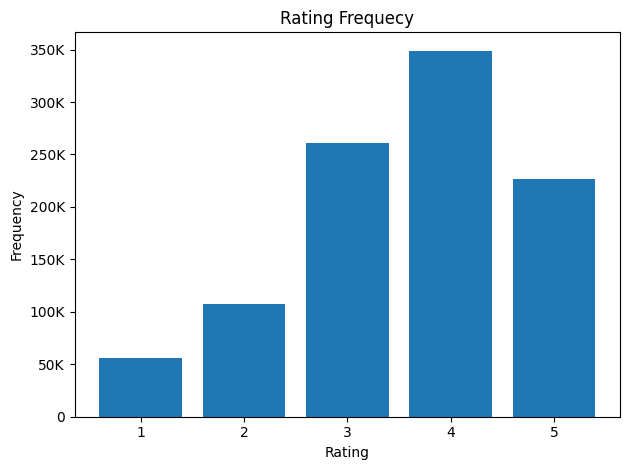

In [17]:
# Plot the FREQUENCY of each rating
# How many 5 stars are there? 4 stars? 3, 2, 1 stars?

rating_counts = ratings["Rating"].value_counts().sort_index()
print(rating_counts)

plt.figure()
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Rating Frequecy")

# Get the current axes and apply the formatter
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000:g}K' if x != 0 else '0'))


plt.tight_layout()
plt.savefig('../figures/rating_frequency.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Plot the FREQUENCY of each rating
# How many 5 stars are there? 4 stars? 3, 2, 1 stars?

rating_counts = ratings["Rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(rating_counts.index, rating_counts.values)

# top and right border invisible
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Title & axis ticks
ax.set_title("Rating Frequency", fontsize=60, pad=0)
ax.tick_params(axis='x', labelsize=40)
ax.tick_params(axis='y', labelsize=30)

# Lower number of Y-axis ticks
# nbins=5 will allow at most 5 intervals on the axis
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000:g}K' if x != 0 else '0'))

plt.tight_layout()
plt.savefig('../figures/rating_frequency_BIG.png', bbox_inches='tight', dpi=300)
plt.show()

# Users & # of ratings

In [18]:
# sort userIDs by # of ratings from least to most
user_sorted_by_amt_of_ratings_dict = dict(sorted(user_counts.items(), key=lambda x: x[1]))

for k, v in user_sorted_by_amt_of_ratings_dict.items():
    print(f"{k}: {v}")

98: 20
160: 20
217: 20
250: 20
311: 20
341: 20
421: 20
572: 20
665: 20
703: 20
708: 20
761: 20
932: 20
947: 20
1351: 20
1406: 20
1452: 20
1493: 20
1664: 20
1844: 20
1993: 20
2037: 20
2061: 20
2111: 20
2128: 20
2133: 20
2160: 20
2292: 20
2381: 20
2488: 20
2530: 20
2584: 20
2673: 20
2696: 20
2714: 20
2759: 20
2819: 20
2884: 20
2930: 20
3021: 20
3222: 20
3273: 20
3291: 20
3376: 20
3407: 20
3530: 20
3552: 20
3633: 20
3787: 20
3883: 20
3969: 20
4068: 20
4178: 20
4192: 20
4244: 20
4332: 20
4365: 20
4383: 20
4393: 20
4398: 20
4419: 20
4463: 20
4525: 20
4527: 20
4547: 20
4628: 20
4749: 20
4775: 20
4991: 20
5012: 20
5027: 20
5145: 20
5159: 20
5168: 20
5215: 20
5216: 20
5258: 20
5309: 20
5314: 20
5380: 20
5525: 20
5533: 20
5725: 20
5828: 20
5904: 20
6038: 20
4: 21
89: 21
94: 21
226: 21
317: 21
318: 21
320: 21
356: 21
383: 21
535: 21
559: 21
574: 21
640: 21
653: 21
821: 21
833: 21
906: 21
907: 21
951: 21
1070: 21
1126: 21
1226: 21
1250: 21
1282: 21
1305: 21
1307: 21
1318: 21
1363: 21
1431: 21
145

In [19]:
# sort userIDs by ID & Display how many movies they rated
user_sorted_by_amt_of_ratings_dict = dict(sorted(user_counts.items(), key=lambda x: x[0]))

for k, v in user_sorted_by_amt_of_ratings_dict.items():
    print(f"{k}: {v}")

1: 53
2: 129
3: 51
4: 21
5: 198
6: 71
7: 31
8: 139
9: 106
10: 401
11: 137
12: 23
13: 108
14: 25
15: 201
16: 35
17: 211
18: 305
19: 255
20: 24
21: 22
22: 297
23: 304
24: 136
25: 85
26: 400
27: 70
28: 107
29: 108
30: 43
31: 119
32: 48
33: 391
34: 164
35: 198
36: 351
37: 53
38: 100
39: 62
40: 96
41: 25
42: 231
43: 24
44: 193
45: 297
46: 41
47: 22
48: 598
49: 108
50: 43
51: 40
52: 79
53: 684
54: 40
55: 25
56: 67
57: 64
58: 437
59: 213
60: 70
61: 36
62: 498
63: 98
64: 27
65: 121
66: 26
67: 64
68: 72
69: 65
70: 54
71: 29
72: 43
73: 255
74: 43
75: 175
76: 87
77: 39
78: 140
79: 31
80: 48
81: 86
82: 118
83: 99
84: 31
85: 39
86: 48
87: 59
88: 68
89: 21
90: 225
91: 44
92: 430
93: 220
94: 21
95: 99
96: 81
97: 154
98: 20
99: 107
100: 76
101: 106
102: 132
103: 115
104: 46
105: 61
106: 47
107: 121
108: 37
109: 81
110: 80
111: 92
112: 60
113: 68
114: 98
115: 38
116: 86
117: 505
118: 224
119: 105
120: 63
121: 72
122: 57
123: 608
124: 23
125: 71
126: 51
127: 174
128: 22
129: 158
130: 135
131: 295
132: 8

In [20]:
# For each user, print how many of each rating they've done

# Get counts per user per rating
user_rating_counts = ratings.groupby(['UserID', 'Rating']).size().unstack(fill_value=0)

# Print for each user
print(f"{'User':<8} {'1':<6} {'2':<6} {'3':<6} {'4':<6} {'5':<6}")
print("-" * 40)
for user_id, row in user_rating_counts.iterrows():
    counts = row.values
    print(f"{user_id:<8} {counts[0]:<6} {counts[1]:<6} {counts[2]:<6} {counts[3]:<6} {counts[4]:<6}")

User     1      2      3      4      5     
----------------------------------------
1        0      0      8      27     18    
2        2      11     43     39     34    
3        1      4      9      22     15    
4        1      1      1      8      10    
5        19     36     61     61     21    
6        1      1      19     33     17    
7        0      0      5      11     15    
8        0      7      47     40     45    
9        0      8      29     52     17    
10       0      12     84     151    154   
11       22     15     32     39     29    
12       1      1      7      6      8     
13       1      7      60     29     11    
14       4      3      5      7      6     
15       4      30     68     95     4     
16       4      9      9      8      5     
17       0      9      35     98     69    
18       41     19     51     89     105   
19       11     30     71     88     55    
20       0      1      4      11     8     
21       6      0      10     2    

# See which Movie IDs are missing

In [21]:
num_movies = len(movies)
print(num_movies)

# README says there are 3952 movie IDs
# But there are only 3883 movies

3883


In [22]:
movieIDs_in_ratings = list(ratings.groupby('MovieID').groups.keys())

foo = len(movieIDs_in_ratings)
print(foo)
# print(movieIDs_in_ratings)
# There are only 3706 unique movie IDs in rating??

3706


In [23]:
counter = 0
i = 1
# 1 to 3952
while i <= foo: 
    movieID = movieIDs_in_ratings[i-1]
    if movieID != i+counter:
        # print("i: ", i)
        # print("ID: ", movieID)
        counter += 1
        # i += 1
    i += 1

print(counter)

246


In [24]:
# Movie IDs go from 1 to 3952
# But some IDs are missing
# There are only 3883 rows in the file
# So 69 IDs must be skipped
3952 - 3883

69

In [25]:
# Out of the 3883 rows in ratings.dat
# When grouping by ID, I found only 3706 movies
# SO: Only 3706 movies HAVE ratings
# There are 177 movies that DO NOT have ratings.
# So there are 3706 total MovieIDs
3883 - 3706

177

In [26]:
# So, there are 69 IDs that are nonexistent
# And 177 movieIDs that DO exist, but have NO reviews
69 + 177

246

In [27]:
# MovieIDs go from 1 to 3952
# There are only 3706 movies with IDs and existing Reviews
# There are 246 movies that have no ID or no reviews
3952 - 3706

246

In [28]:
# Get all movies that exist in the metadata file
all_movie_ids = set(movies['MovieID'])

# Get the movie IDs with ratings
rated_movie_ids = set(ratings['MovieID'].unique())

# Get the IDs in movies.dat but NOT in ratings.dat
ghost_ids = sorted(list(all_movie_ids - rated_movie_ids))

print(f"Number of unrated Movies: {len(ghost_ids)}")

# Print titles of these non-rated movies
ghost_movies_titles = movies[movies['MovieID'].isin(ghost_ids)]
print(ghost_movies_titles[['MovieID', 'Title']].head(50))

Number of unrated Movies: 177
     MovieID                                              Title
50        51                              Guardian Angel (1994)
107      109                Headless Body in Topless Bar (1995)
113      115                   Happiness Is in the Field (1995)
141      143                                       Gospa (1995)
281      284                                New York Cop (1996)
282      285                               Beyond Bedlam (1993)
391      395                                Desert Winds (1995)
395      399                        Girl in the Cadillac (1995)
396      400                                      Homage (1995)
399      403                                  Two Crimes (1995)
600      604                                   Criminals (1996)
616      620          Scream of Stone (Schrei aus Stein) (1991)
620      625                                 Asfour Stah (1990)
624      629                                        Rude (1995)
631      6

In [29]:
# Find the 69 potential ID numbers that have been skipped over (Non-Existent IDs)
# Range is 1 to 3952 inclusive
all_possible_ids = set(range(1, 3953))
existing_movie_ids = set(movies['MovieID'])
non_existent_ids = sorted(list(all_possible_ids - existing_movie_ids))

print(f"List length: {len(non_existent_ids)}")
print(f"The non-existent IDs: {non_existent_ids}")

# DOUBLE CHECK: Try to find these IDs in the movies dataframe
check_in_movies = movies[movies['MovieID'].isin(non_existent_ids)]

if check_in_movies.empty:
    print("\nVerification Successful: None of these 69 IDs exist in movies.dat.")
else:
    print(f"\nError: Found {len(check_in_movies)} of these IDs in movies.dat.")

List length: 69
The non-existent IDs: [91, 221, 323, 622, 646, 677, 686, 689, 740, 817, 883, 995, 1048, 1072, 1074, 1182, 1195, 1229, 1239, 1338, 1402, 1403, 1418, 1435, 1451, 1452, 1469, 1478, 1481, 1491, 1492, 1505, 1506, 1512, 1521, 1530, 1536, 1540, 1560, 1576, 1607, 1618, 1634, 1637, 1638, 1691, 1700, 1712, 1736, 1737, 1745, 1751, 1761, 1763, 1766, 1775, 1778, 1786, 1790, 1800, 1802, 1803, 1808, 1813, 1818, 1823, 1828, 1838, 3815]

Verification Successful: None of these 69 IDs exist in movies.dat.


In [30]:
# For each movie, print how many of each rating they have

# Get counts per movie per rating
movie_rating_counts = ratings.groupby(['MovieID', 'Rating']).size().unstack(fill_value=0)

movie_rating_counts['total'] = movie_rating_counts.sum(axis=1)
movie_rating_counts['avg_rating'] = (
    movie_rating_counts[1] * 1 + 
    movie_rating_counts[2] * 2 + 
    movie_rating_counts[3] * 3 + 
    movie_rating_counts[4] * 4 + 
    movie_rating_counts[5] * 5
) / movie_rating_counts['total']

movie_rating_counts = movie_rating_counts.sort_values('avg_rating', ascending=False)

# Print for each movie
print(f"{'MovieID':<10} {'1':<6} {'2':<6} {'3':<6} {'4':<6} {'5':<6} {'Avg':<8} {'Total':<6}")
print("-" * 65)
for movie_id, row in movie_rating_counts.iterrows():
    counts = [row[1], row[2], row[3], row[4], row[5]]
    print(f"{movie_id:<10} {counts[0]:<6} {counts[1]:<6} {counts[2]:<6} {counts[3]:<6} {counts[4]:<6} {row['avg_rating']:<8.2f} {row['total']:<6}")

MovieID    1      2      3      4      5      Avg      Total 
-----------------------------------------------------------------
989        0.0    0.0    0.0    0.0    1.0    5.00     1.0   
3881       0.0    0.0    0.0    0.0    1.0    5.00     1.0   
1830       0.0    0.0    0.0    0.0    1.0    5.00     1.0   
3382       0.0    0.0    0.0    0.0    1.0    5.00     1.0   
787        0.0    0.0    0.0    0.0    3.0    5.00     3.0   
3280       0.0    0.0    0.0    0.0    1.0    5.00     1.0   
3607       0.0    0.0    0.0    0.0    1.0    5.00     1.0   
3233       0.0    0.0    0.0    0.0    2.0    5.00     2.0   
3172       0.0    0.0    0.0    0.0    1.0    5.00     1.0   
3656       0.0    0.0    0.0    0.0    1.0    5.00     1.0   
3245       0.0    0.0    0.0    1.0    4.0    4.80     5.0   
53         0.0    0.0    0.0    2.0    6.0    4.75     8.0   
2503       0.0    0.0    0.0    3.0    6.0    4.67     9.0   
2905       0.0    1.0    1.0    22.0   45.0   4.61     69.0  
2019

In [31]:
# Print MovidID & Title
for index, row in movies.iterrows():
    print(f"{row['MovieID']}: Title: {row['Title']}")

1: Title: Toy Story (1995)
2: Title: Jumanji (1995)
3: Title: Grumpier Old Men (1995)
4: Title: Waiting to Exhale (1995)
5: Title: Father of the Bride Part II (1995)
6: Title: Heat (1995)
7: Title: Sabrina (1995)
8: Title: Tom and Huck (1995)
9: Title: Sudden Death (1995)
10: Title: GoldenEye (1995)
11: Title: American President, The (1995)
12: Title: Dracula: Dead and Loving It (1995)
13: Title: Balto (1995)
14: Title: Nixon (1995)
15: Title: Cutthroat Island (1995)
16: Title: Casino (1995)
17: Title: Sense and Sensibility (1995)
18: Title: Four Rooms (1995)
19: Title: Ace Ventura: When Nature Calls (1995)
20: Title: Money Train (1995)
21: Title: Get Shorty (1995)
22: Title: Copycat (1995)
23: Title: Assassins (1995)
24: Title: Powder (1995)
25: Title: Leaving Las Vegas (1995)
26: Title: Othello (1995)
27: Title: Now and Then (1995)
28: Title: Persuasion (1995)
29: Title: City of Lost Children, The (1995)
30: Title: Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)
31: Title: Dange

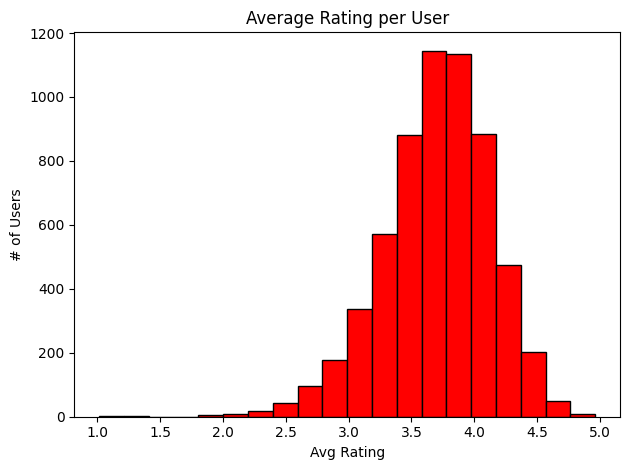

In [32]:
# Average rating per user
user_avg = ratings.groupby('UserID')['Rating'].mean()
plt.hist(user_avg, bins=20, edgecolor='black', color='red')
plt.title('Average Rating per User')
plt.xlabel('Avg Rating')
plt.ylabel('# of Users')

plt.tight_layout()
plt.savefig('../figures/avg_rating_per_user.png', bbox_inches='tight', dpi=300)
plt.show()

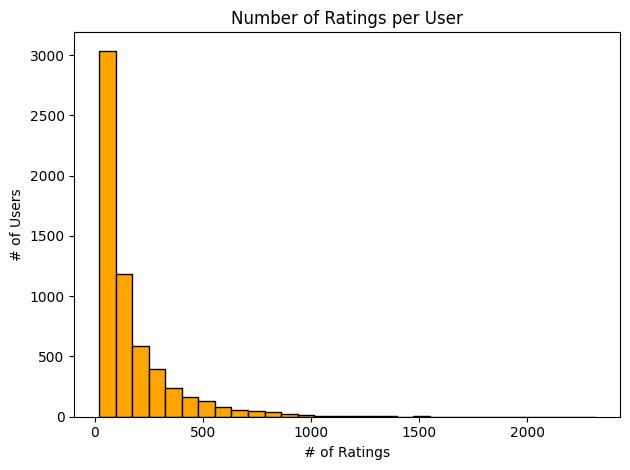

In [33]:
# Number of ratings per user
user_counts = ratings.groupby('UserID').size()
plt.hist(user_counts, bins=30, edgecolor='black', color='orange')
plt.title('Number of Ratings per User')
plt.xlabel('# of Ratings')
plt.ylabel('# of Users')

plt.tight_layout()
plt.savefig('../figures/number_of_ratings_per_user.png', bbox_inches='tight', dpi=300)
plt.show()